Definitive chart of clustered cores are drawn. Optimal number of cluster is already choosen.

In [ ]:
from notebook_utils import cd2parent
cd2parent()

In [2]:
import pandas as pd
import numpy as np
import os

from matplotlib import pyplot as plt

from src.dataloader import Dataloader

from rdkit import Chem
from rdkit.Chem import Draw

# Data loading

In [3]:
dataloader = Dataloader()
dataloader.load_scores()
dataloader.load_cores()

In [4]:
n_cluster = 5
clusterizer = 'kmedoids'
seed = 0

In [5]:
scores = dataloader.scores.set_index('smiles')

cluster_data = dataloader.get_local_cluster(clusterizer=clusterizer, seed=0, size=n_cluster)

data_plot = scores.merge(cluster_data[['cluster']], on='smiles', how='outer')
data_plot.fillna(-1.0, inplace=True)
data_plot['cluster'] = data_plot['cluster'].astype(int)
data_plot

,PC1,PC2,PC3,cluster
smiles,,,,
C1CC12CNC2,-2.126480,-1.394821,-0.048237,0
C1CC12COC2,-3.944747,-0.738331,-0.712663,0
C1CC2(C1)CC2,-3.637770,-3.791764,0.713959,0
C1CC2(C1)CCN2,-1.502594,-1.621151,1.017377,0
C1CC2(C1)CCO2,-3.524344,-0.909225,0.603360,0
...,...,...,...,...
c1ccncc1,-3.428281,-1.022633,2.396890,0
c1ccoc1,-4.755463,-2.043546,2.061793,0
c1cnoc1,-3.997331,0.145278,1.336859,0


In [6]:
centroids = data_plot.groupby('cluster').agg('mean')
centroids

,PC1,PC2,PC3
cluster,,,
-1,2.011363,1.367491,-1.539016
0,-3.292050,-0.850655,0.139940
1,0.234557,2.732335,0.328710
2,1.949104,-0.261592,1.748160
3,2.762493,-1.778823,-1.470898
4,0.017168,-0.065053,-0.916239


# Distances

In [7]:
from src.dataloader import special_cores

In [8]:
special_cores

['C1CCNCC1', 'C1CC12COC2', 'C1CC2(C1)CC2', 'C1CC12CNC2']

In [9]:
names_cores = dataloader.cores.set_index('smiles').loc[special_cores,'name']

In [10]:
names_cores

smiles
C1CCNCC1                   piperidine
C1CC12COC2      5-oxaspiro[2.3]hexane
C1CC2(C1)CC2         spiro[2.3]hexane
C1CC12CNC2      5-azaspiro[2.3]hexane
Name: name, dtype: object

In [11]:
for smiles_core, name_core in names_cores.items():
	data_plot[f'{name_core}_distance'] = np.linalg.norm(
		data_plot.loc[[smiles_core],['PC1','PC2','PC3']].values - \
		data_plot[['PC1','PC2','PC3']].values,
		keepdims=False,
		axis=1
	)

	centroids[f'{name_core}_distance'] = np.linalg.norm(
		data_plot.loc[[smiles_core],['PC1','PC2','PC3']].values - \
		centroids[['PC1','PC2','PC3']].values,
		keepdims=False,
		axis=1
	)

In [12]:
centroids

,PC1,PC2,PC3,piperidine_distance,5-oxaspiro[2.3]hexane_distance,spiro[2.3]hexane_distance,5-azaspiro[2.3]hexane_distance
cluster,,,,,,,
-1,2.011363,1.367491,-1.539016,5.093270,6.371232,7.975369,5.193702
0,-3.292050,-0.850655,0.139940,2.884456,1.079612,3.016478,1.300030
1,0.234557,2.732335,0.328710,5.156198,5.531416,7.596525,4.769696
2,1.949104,-0.261592,1.748160,3.658992,6.404719,6.689159,4.595829
3,2.762493,-1.778823,-1.470898,4.156828,6.829686,7.056125,5.106220
4,0.017168,-0.065053,-0.916239,2.807749,4.023869,5.468500,2.667760


In [13]:
for smiles_core, name_core in names_cores.items():
	cluster_core = data_plot.loc[smiles_core,'cluster']
	stats = data_plot.query('cluster == @cluster_core').drop(index = smiles_core)[f'{name_core}_distance'].describe()
	mean_value = stats['mean'].round(2)
	std_value = stats['std'].round(2)

	print('intra-cluster distance for', name_core, ':',mean_value,'±',std_value)

intra-cluster distance for piperidine : 3.2 ± 0.77
intra-cluster distance for 5-oxaspiro[2.3]hexane : 2.24 ± 0.91
intra-cluster distance for spiro[2.3]hexane : 3.59 ± 1.18
intra-cluster distance for 5-azaspiro[2.3]hexane : 2.28 ± 1.11


# Plot requirements

In [14]:
hexans = [
    'C1OCC12CO2',
	'C1NC12COC2',
	'C1CC12COC2',
	'C1NCC12CO2',
	'C1NCC12CN2',
	'C1CC12CNC2',
	'C1CC2(C1)CO2',
	'C1CC2(C1)CN2',
	'C1CC2(C1)CC2',
]

aromatic_cycles =[
    'c1ccncc1',
    'c1cnoc1',
]

highlighted_cores = set(special_cores + hexans + aromatic_cycles)

In [15]:
# Drawing and saving mol figures (replacing the main cores, in case of figure c has already provided them)
from src.utils import drawMol

dir_special_cores = os.path.join('figures', 'special_cores')
os.makedirs(dir_special_cores, exist_ok=True)

for special_core in highlighted_cores:
	svg = drawMol(Chem.MolFromSmiles(special_core))
	path_svg_mol = os.path.join(dir_special_cores,f'{special_core}.svg')
	with open(path_svg_mol, 'w') as f:
		f.write(svg)

In [16]:
cmap={
    -1 : 'gray',
    0 : "#3737BE",
    1 : '#008080',
    2 : '#CBE6FF',
    3: '#FDCBC3',
    4: "#962F2F",
}

In [17]:

data_plot = scores.merge(cluster_data[['cluster']], on='smiles', how='outer')
data_plot.fillna(-1.0, inplace=True)
data_plot['cluster'] = data_plot['cluster'].astype(int)

# data_plot['color'] = data_plot['cluster'].apply(lambda x: cmap(x) if x >= 0 else 'gray')
data_plot['color'] = data_plot['cluster'].apply(lambda x: cmap[x])
data_plot['linewidth'] = data_plot.index.to_series().apply(lambda idx: 2 if idx in highlighted_cores else 0)
data_plot['edgecolor'] = data_plot.index.to_series().apply(lambda idx: 'black' if idx in highlighted_cores else 'none')
data_plot

,PC1,PC2,PC3,cluster,color,linewidth,edgecolor
smiles,,,,,,,
C1CC12CNC2,-2.126480,-1.394821,-0.048237,0,#3737BE,2,black
C1CC12COC2,-3.944747,-0.738331,-0.712663,0,#3737BE,2,black
C1CC2(C1)CC2,-3.637770,-3.791764,0.713959,0,#3737BE,2,black
C1CC2(C1)CCN2,-1.502594,-1.621151,1.017377,0,#3737BE,0,none
C1CC2(C1)CCO2,-3.524344,-0.909225,0.603360,0,#3737BE,0,none
...,...,...,...,...,...,...,...
c1ccncc1,-3.428281,-1.022633,2.396890,0,#3737BE,2,black
c1ccoc1,-4.755463,-2.043546,2.061793,0,#3737BE,0,none
c1cnoc1,-3.997331,0.145278,1.336859,0,#3737BE,2,black


In [18]:
# Cluster to zoom
zoom_cluster = 4

constant_dim = 1 # 1 means y (PC 2)
dims = [0,1,2]
dims.remove(constant_dim)

pad_value = .3

subset_zoom = data_plot.query('linewidth > 0 and cluster == @zoom_cluster')

coords = subset_zoom.iloc[:,dims].values

constant_anchor = subset_zoom.iloc[:,constant_dim].mean()

min_values = np.min(coords, axis=0) - pad_value
max_values = np.max(coords, axis=0) + pad_value

# Clusters checking

In [19]:
grp_cluster = data_plot.reset_index(drop=False).groupby('cluster').agg(tuple)
figures_cluster = [
    Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in list_smiles], molsPerRow = 6)
    for list_smiles in grp_cluster.smiles
]

In [20]:
grp_cluster.index

Index([-1, 0, 1, 2, 3, 4], dtype='int64', name='cluster')

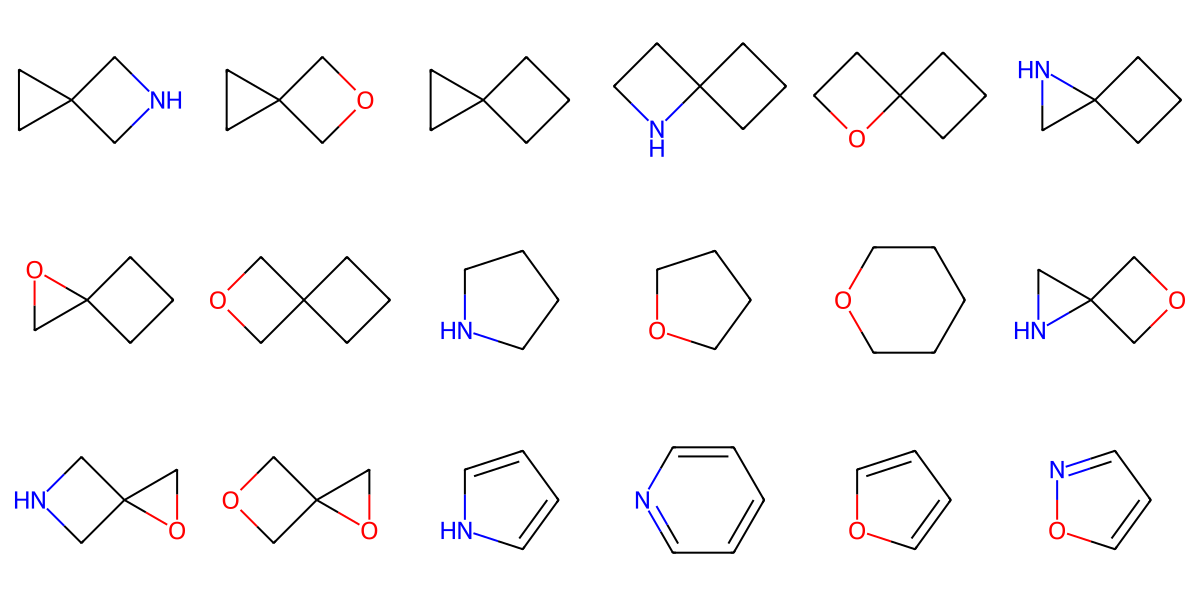

In [21]:
figures_cluster[1]

In [22]:
dir_clusters_figs = os.path.join('figures','clusters')
for cluster_idx, row in grp_cluster.iterrows():
	list_smiles = row.smiles
	img = Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in list_smiles], molsPerRow = 6, returnPNG=False)
	img.save(os.path.join(dir_clusters_figs, f'cluster_{cluster_idx+1}.png'))

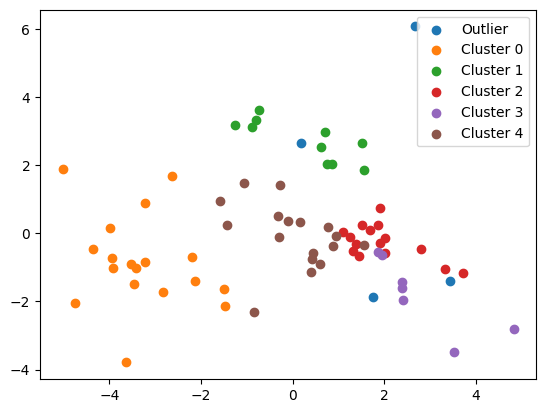

In [23]:
fig,ax = plt.subplots()

for label, row in grp_cluster.iterrows():
	sub_set = scores[scores.index.isin(row.smiles)]

	label_str = 'Cluster ' + str(label) if label >=0 else 'Outlier'

	ax.scatter(*sub_set.values[:,:2].T, label=label_str)

ax.legend()

# Matplot figure

In [24]:
from matplotlib import pyplot as plt
import mpl_toolkits.mplot3d.art3d as art3d
from matplotlib import patches

Text(0, 0.5, 'PC 3')

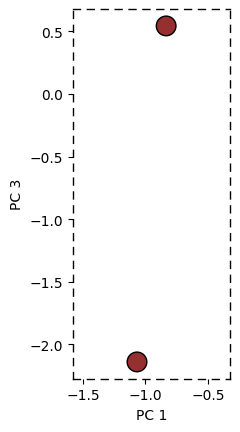

In [25]:
fig_zoom, ax = plt.subplots(1,1)

ax.scatter(
    *subset_zoom.iloc[:,dims].values.T,
    s=200,
	color=subset_zoom['color'],
    edgecolors=subset_zoom['edgecolor'],
)

x_min, x_max = ax.get_xlim()

ax.set_xlim(x_min-.5, x_max+.5)

ax.set_aspect('equal')

for spine in ax.spines.values():
	spine.set_linestyle((0,(5,5)))
	spine.set_linewidth(1)

ax.set_xlabel(f'PC {dims[0]+1}')
ax.set_ylabel(f'PC {dims[1]+1}')

In [26]:
dir_clutser_plots = os.path.join('figures','cluster_plots')
fig_zoom.savefig(os.path.join(dir_clutser_plots,'cluster_zoom.svg'), bbox_inches='tight', transparent=True)

In [27]:
def makesphere(x, y, z, radius=0.2, resolution=20):
    """Return the coordinates for plotting a sphere centered at (x,y,z)"""
    u, v = np.mgrid[0:2*np.pi:resolution*2j, 0:np.pi:resolution*1j]
    X = radius * np.cos(u)*np.sin(v) + x
    Y = radius * np.sin(u)*np.sin(v) + y
    Z = radius * np.cos(v) + z
    return (X, Y, Z)

In [28]:
panel_colors = [
    '#8B97BF',
    # "#6D78A8",
	'#9EADDEFF',
    "#A6AFD1",
]


In [29]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['font.size'] = 16

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d', azim=-100, elev=5)

from matplotlib.colors import LightSource
ls = LightSource(-100, 5)
for smi,row in data_plot.iterrows():
	X, Y, Z = makesphere(*row.iloc[:3].values.T, resolution=10)
	ax.plot_surface(X, Y, Z, color=row['color'], lightsource=ls, rasterized=True)

	if smi in special_cores:
		ax.text(*row.iloc[:3].values.T, smi, None)

ax.tick_params(colors='#808080', labelsize=11)

ax.set_xlabel(r'$\mathbfit{PC 1}$', labelpad=15, color='#000080')
ax.set_ylabel(r'$\mathbfit{PC 2}$', labelpad=15, color='#000080')
ax.set_zlabel(r'$\mathbfit{PC 3}$', labelpad=15, color='#000080')

ax.xaxis.set_pane_color(panel_colors[0])
ax.yaxis.set_pane_color(panel_colors[1])
ax.zaxis.set_pane_color(panel_colors[2])

ax.xaxis.line.set_color('#808080')
ax.yaxis.line.set_color('#808080')
ax.zaxis.line.set_color('#808080')

ax.xaxis._axinfo["grid"]['color']="lightgray"
ax.yaxis._axinfo["grid"]['color']="lightgray"
ax.zaxis._axinfo["grid"]['color']="lightgray"

# ax.set_box_aspect(aspect=(0.7, 1, 0.7), zoom=1.2)
ax.set_box_aspect(aspect=(0.9, 1, 0.55), zoom=1)

fig.tight_layout(pad=0)
plt.show()


In [30]:
# Depth initialization

# Sources direction
p1 = np.array([-5, -4, -1])
p2 = np.array([4, 6, 3])

import numpy as np

def scale_from_view(point, p1=p1, p2=p2, min_scale=0.1, max_scale=1.0):
    # Distance from PoV
    d = np.linalg.norm(point - p1)

    # Max distance
    max_d = np.linalg.norm(p2 - p1)

    # clamp
    t = 1 - np.clip(d / max_d, 0, 1)

    # scaling
    scale = min_scale + t * (max_scale - min_scale)

    return float(scale)


In [ ]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d', azim=-100, elev=5)

from matplotlib.colors import LightSource
ls = LightSource(120, 5)
for smi,row in data_plot.iterrows():
	X, Y, Z = makesphere(*row.iloc[:3].values.T, resolution=10)
	ax.plot_surface(X, Y, Z, color=row['color'], lightsource=ls, rasterized=True)

	if smi in special_cores:
		ax.text(*row.iloc[:3].values.T, smi, None)

ax.tick_params(colors="#262222", labelsize=11)

ax.set_xlabel(r'$\mathbfit{PC 1}$', labelpad=15, color='#000080')
ax.set_ylabel(r'$\mathbfit{PC 2}$', labelpad=15, color='#000080')
ax.set_zlabel(r'$\mathbfit{PC 3}$', labelpad=15, color='#000080')

ax.xaxis.line.set_color('#262222')
ax.yaxis.line.set_color('#262222')
ax.zaxis.line.set_color('#262222')

ax.xaxis._axinfo["grid"]['color']="lightgray"
ax.yaxis._axinfo["grid"]['color']="lightgray"
ax.zaxis._axinfo["grid"]['color']="lightgray"

ax.set_box_aspect(aspect=(0.9, 1, 0.55), zoom=1)

fig.tight_layout(pad=0)
plt.show()


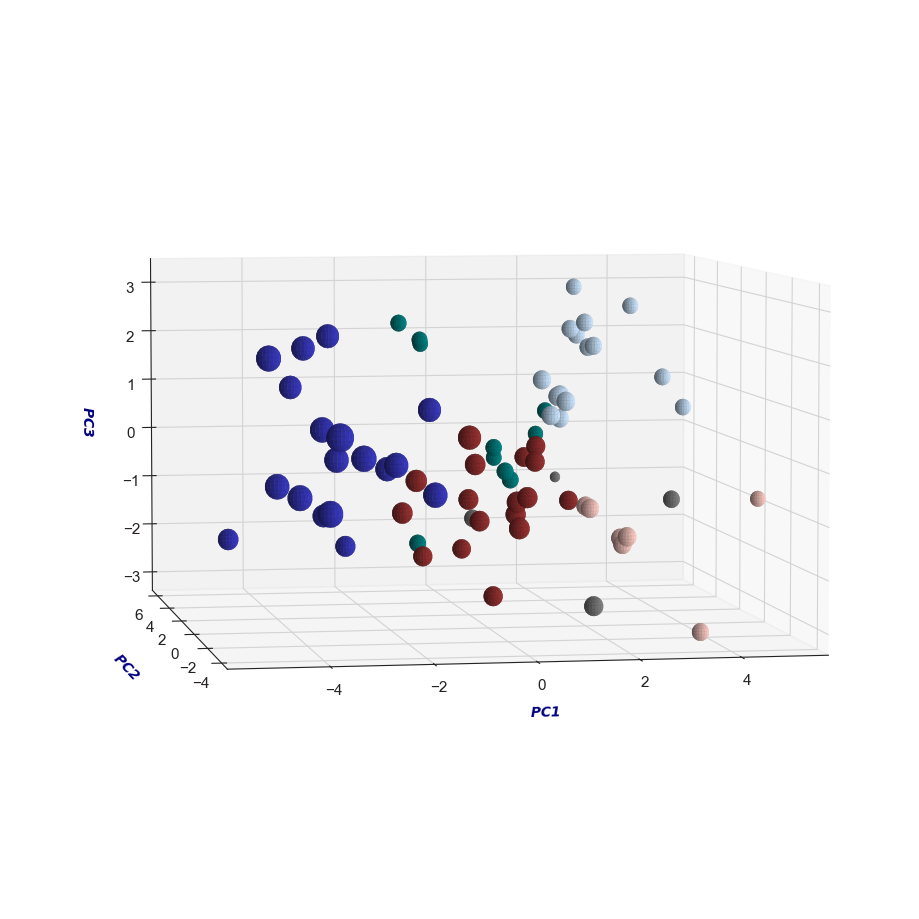

In [31]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d', azim=-100, elev=5)

from matplotlib.colors import LightSource
ls = LightSource(120, 5)
for smi,row in data_plot.iterrows():
	scaling_value= scale_from_view(row.iloc[:3].values, min_scale=0.3)
	X, Y, Z = makesphere(*row.iloc[:3].values.T, radius=0.3*scaling_value, resolution=10)
	ax.plot_surface(X, Y, Z, color=row['color'], lightsource=ls, rasterized=True, alpha =1 )

ax.tick_params(colors="#262222", labelsize=11)

ax.set_xlabel(r'$\mathbfit{PC 1}$', labelpad=15, color='#000080')
ax.set_ylabel(r'$\mathbfit{PC 2}$', labelpad=15, color='#000080')
ax.set_zlabel(r'$\mathbfit{PC 3}$', labelpad=15, color='#000080')

# ax.xaxis.set_pane_color(panel_colors[0])
# ax.yaxis.set_pane_color(panel_colors[1])
# ax.zaxis.set_pane_color(panel_colors[2])

ax.xaxis.line.set_color('#262222')
ax.yaxis.line.set_color('#262222')
ax.zaxis.line.set_color('#262222')

ax.xaxis._axinfo["grid"]['color']="lightgray"
ax.yaxis._axinfo["grid"]['color']="lightgray"
ax.zaxis._axinfo["grid"]['color']="lightgray"

ax.set_box_aspect(aspect=(0.9, 1, 0.55), zoom=1)

fig.tight_layout(pad=0)
plt.show()


In [32]:
fig.savefig(os.path.join('figures','cluster_plots','cluster_depth.svg'), bbox_inches='tight', transparent=True)

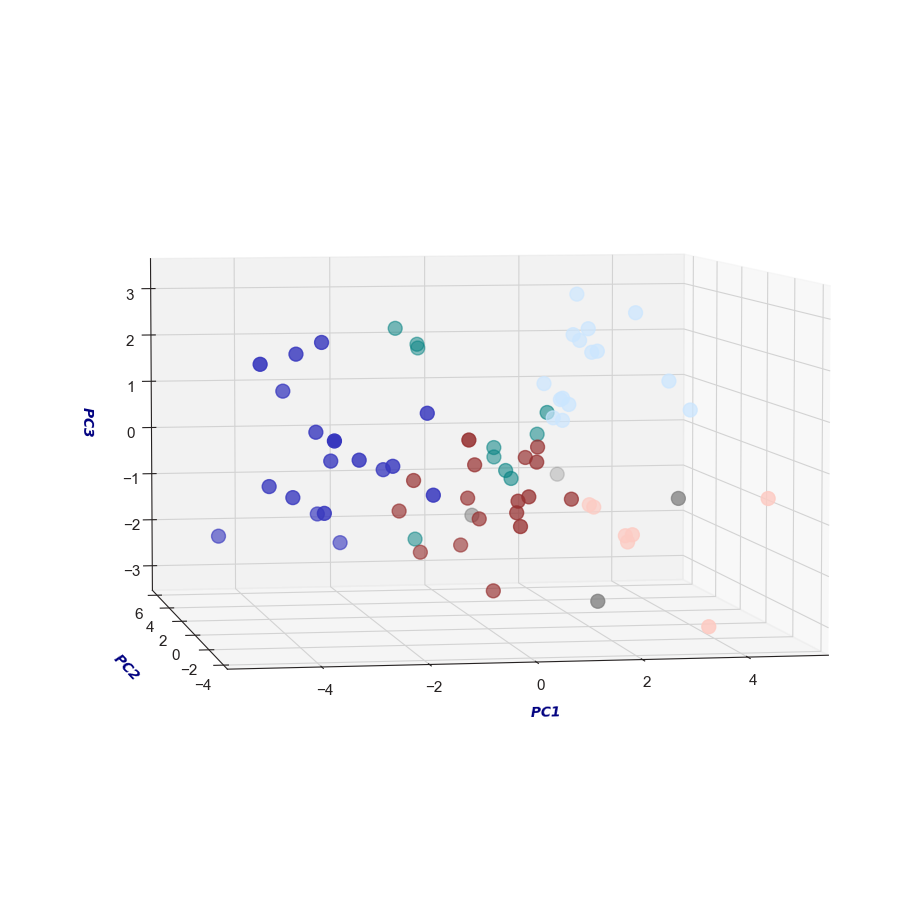

In [33]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d', azim=-100, elev=5)

ax.scatter(
	*data_plot.iloc[:,:3].values.T,
	s=100,
	# alpha=alpha,
	color=data_plot['color'],
	# edgecolors=data_plot['edgecolor'],
	# linewidths=data_plot['linewidth'],
)

ax.tick_params(colors="#262222", labelsize=11)

ax.set_xlabel(r'$\mathbfit{PC 1}$', labelpad=15, color='#000080')
ax.set_ylabel(r'$\mathbfit{PC 2}$', labelpad=15, color='#000080')
ax.set_zlabel(r'$\mathbfit{PC 3}$', labelpad=15, color='#000080')

ax.xaxis.line.set_color('#262222')
ax.yaxis.line.set_color('#262222')
ax.zaxis.line.set_color('#262222')

ax.xaxis._axinfo["grid"]['color']="lightgray"
ax.yaxis._axinfo["grid"]['color']="lightgray"
ax.zaxis._axinfo["grid"]['color']="lightgray"

ax.set_box_aspect(aspect=(0.9, 1, 0.55), zoom=1)

fig.tight_layout(pad=0)
plt.show()


In [34]:
fig.savefig(os.path.join('figures','cluster_plots','cluster_transparency.svg'), bbox_inches='tight', transparent=True)